# 02. Modelado predictivo — LaLiga

Entreno XGBoost con calibración isotónica sobre 2010-2024 y guardo el modelo (`modelo_v3_calibrado.joblib`). Los hiperparámetros salen de una búsqueda con Optuna sobre walk-forward interno, así que no hay fuga temporal en el entrenamiento.

Una nota sobre Optuna: la búsqueda usa solo 2018-2023 y los hiperparámetros se aplican después al backtest 2012-2024 (notebook 03). Para 2012-2017 los hiperparámetros son técnicamente del futuro. No es leakage en el sentido estricto (no se filtra el target) pero sí un sesgo optimista para esas temporadas. Lo dejo documentado; arreglarlo bien implicaría una doble capa de walk-forward y queda como trabajo futuro.

La búsqueda usa `TPESampler(seed=42)` para que sea reproducible.

In [1]:
%pip install pandas numpy joblib xgboost scikit-learn optuna


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\emili\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_PATH  = '../data/df_final_clean.csv'
MODEL_OUT  = '../modelo_v3_calibrado.joblib'

FEATURES = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5',
    'Home_H2H_L3','Away_H2H_L3',
]

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

df = df.dropna(subset=FEATURES + ['Target'])
print(f'Dataset: {len(df)} partidos | Temporadas: {sorted(df["Season"].unique())}')

Dataset: 5700 partidos | Temporadas: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 1. División train / test

Test = temporada 2024. Train = 2010-2023. El modelo no ve 2024 hasta que predice.

In [3]:
TEST_SEASON  = 2024
TRAIN_SEASONS = [s for s in df['Season'].unique() if s < TEST_SEASON]

tr_mask = df['Season'].isin(TRAIN_SEASONS)
te_mask = df['Season'] == TEST_SEASON

X_train = df.loc[tr_mask, FEATURES].values
y_train = df.loc[tr_mask, 'Target'].values
X_test  = df.loc[te_mask, FEATURES].values
y_test  = df.loc[te_mask, 'Target'].values

print(f'Train: {len(X_train)} partidos ({TRAIN_SEASONS[0]}-{TRAIN_SEASONS[-1]})')
print(f'Test : {len(X_test)} partidos ({TEST_SEASON})')
print(f'Distribucion train: H={np.mean(y_train==2):.1%}  D={np.mean(y_train==1):.1%}  A={np.mean(y_train==0):.1%}')


Train: 5320 partidos (2010-2023)
Test : 380 partidos (2024)
Distribucion train: H=46.6%  D=25.0%  A=28.3%


## 2. Optimización de hiperparámetros con Optuna

Minimizo log loss en walk-forward interno (5 folds, una temporada cada uno). Uso 2019-2023 para esto.

In [4]:
# Walk-forward interno para Optuna: ultimas 6 temporadas del train
opt_seasons = sorted(TRAIN_SEASONS)[-6:]
df_opt = df[df['Season'].isin(opt_seasons)].reset_index(drop=True)
X_opt  = df_opt[FEATURES].values
y_opt  = df_opt['Target'].values
s_opt  = df_opt['Season'].values
unique_s = sorted(df_opt['Season'].unique())

def objective(trial):
    params = {
        'objective':        'multi:softprob',
        'num_class':        3,
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 400),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 3.0),
        'random_state': 42, 'verbosity': 0, 'n_jobs': -1,
    }
    losses = []
    # Walk-forward: cada fold usa todas las temporadas anteriores como train
    for i in range(1, len(unique_s)):
        tr_s  = unique_s[:i]
        val_s = unique_s[i]
        tr  = np.isin(s_opt, tr_s)
        val = s_opt == val_s
        m = XGBClassifier(**params)
        m.fit(X_opt[tr], y_opt[tr])
        losses.append(log_loss(y_opt[val], m.predict_proba(X_opt[val])))
    return np.mean(losses)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(f'Mejor Log-Loss: {study.best_value:.4f}')
print(f'Mejores params: {study.best_params}')


Best trial: 33. Best value: 0.997338: 100%|██████████| 50/50 [01:56<00:00,  2.33s/it]

Mejor Log-Loss: 0.9973
Mejores params: {'max_depth': 2, 'learning_rate': 0.012781205788933974, 'n_estimators': 288, 'subsample': 0.8880288011400305, 'colsample_bytree': 0.8109839241188007, 'reg_alpha': 1.7393227079188538, 'reg_lambda': 1.7066902348160196}


## 3. Entrenamiento final y calibración isotónica

In [5]:
best = study.best_params.copy()
best.update({'objective':'multi:softprob','num_class':3,
             'random_state':42,'verbosity':0,'n_jobs':-1})

base_model  = XGBClassifier(**best)
# TimeSeriesSplit respeta el orden temporal: nunca usa datos futuros para calibrar
tss = TimeSeriesSplit(n_splits=3)
final_model = CalibratedClassifierCV(base_model, method='isotonic', cv=tss)
final_model.fit(X_train, y_train)

# Evaluacion en test
probs = final_model.predict_proba(X_test)
preds = final_model.predict(X_test)
acc   = accuracy_score(y_test, preds)
ll    = log_loss(y_test, probs)

# Brier score para victoria local (clase 2)
classes = list(final_model.classes_)
p_home  = probs[:, classes.index(2)]
brier   = brier_score_loss((y_test == 2).astype(int), p_home)

print('=' * 45)
print('EVALUACION EN TEST (2024, out-of-sample)')
print('=' * 45)
print(f'  Accuracy : {acc:.2%}')
print(f'  Log-Loss : {ll:.4f}  (referencia naive: ~1.099)')
print(f'  Brier(H) : {brier:.4f}  (menor = mejor calibracion)')
print(f'  Calibracion: TimeSeriesSplit(n_splits=3) — sin leakage temporal')

EVALUACION EN TEST (2024, out-of-sample)
  Accuracy : 51.84%
  Log-Loss : 0.9879  (referencia naive: ~1.099)
  Brier(H) : 0.2136  (menor = mejor calibracion)
  Calibracion: TimeSeriesSplit(n_splits=3) — sin leakage temporal


In [6]:
%pip install matplotlib



Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\emili\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 4. Curva de calibración

Compruebo que las probabilidades predichas se acerquen a las frecuencias reales. Un modelo bien calibrado sigue la diagonal.

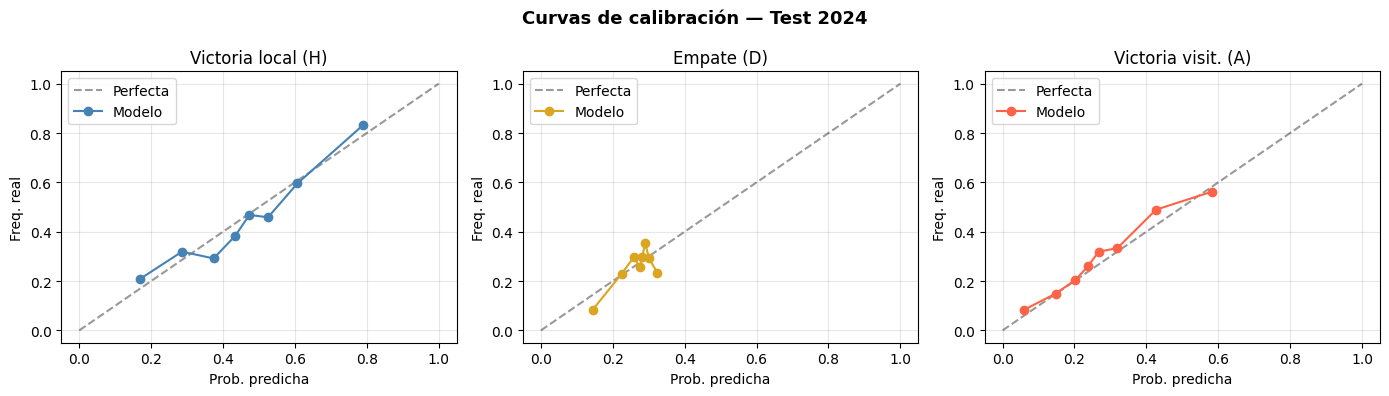

Guardado: results/calibracion_2024.png


In [7]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
outcome_names = {0: 'Victoria visitante (A)', 1: 'Empate (D)', 2: 'Victoria local (H)'}
colors = ['steelblue', 'goldenrod', 'tomato']

for idx, (cls, name, color) in enumerate(zip([2, 1, 0],
    ['Victoria local (H)', 'Empate (D)', 'Victoria visit. (A)'], colors)):
    p_cls = probs[:, classes.index(cls)]
    y_bin = (y_test == cls).astype(int)
    prob_true, prob_pred = calibration_curve(y_bin, p_cls, n_bins=8, strategy='quantile')
    ax = axes[idx]
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfecta')
    ax.plot(prob_pred, prob_true, 'o-', color=color, label='Modelo')
    ax.set_title(name)
    ax.set_xlabel('Prob. predicha')
    ax.set_ylabel('Freq. real')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Curvas de calibración — Test 2024', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/calibracion_2024.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: results/calibracion_2024.png')


## 5. Importancia de variables

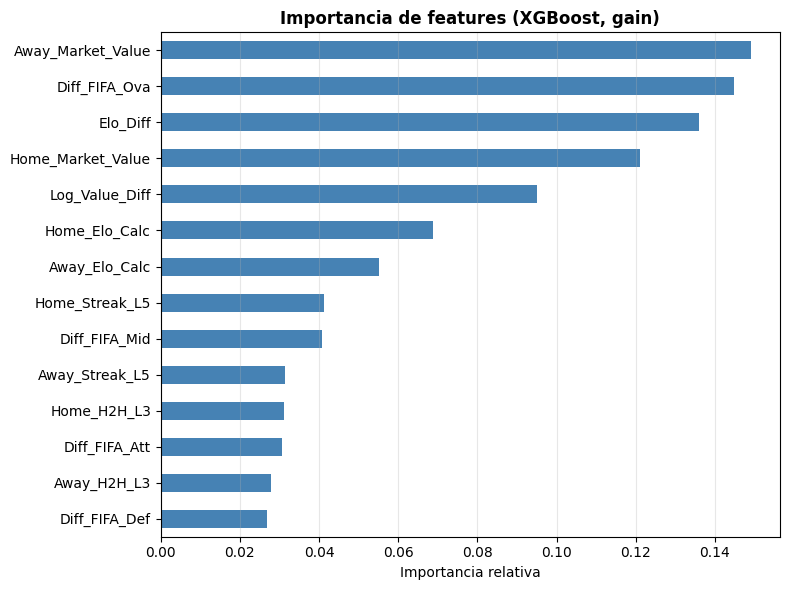

In [8]:
# Extraer importancias del estimador base (primer calibrador)
import pandas as pd
base = final_model.calibrated_classifiers_[0].estimator
fi   = pd.Series(base.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importancia de features (XGBoost, gain)', fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/feature_importance_v3.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Guardar modelo

In [9]:
joblib.dump(final_model, MODEL_OUT)
print(f'Modelo guardado: {MODEL_OUT}')

# Guardar tambien los mejores params para reproducibilidad
import json
with open('../results/best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)
print('Params guardados: results/best_params.json')


Modelo guardado: ../modelo_v3_calibrado.joblib
Params guardados: results/best_params.json
